In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [2]:
customers = pd.read_csv("customers.csv",header=1)
plans = pd.read_csv("plans.csv",header=3)
events = pd.read_csv("subscriptions_events.csv",header=1)

## Step 1 — Exploratory Data Analysis (EDA)

In [3]:
customers.head()

,customer_id,signup_date,signup_month,initial_plan,billing_cycle,acquisition_channel,region
0,CUST0001,2023-01-09,2023-01,Growth,Monthly,Paid Ads,South
1,CUST0002,2023-01-24,2023-01,Starter,Monthly,Partner,North
2,CUST0003,2023-01-03,2023-01,Growth,Monthly,Paid Ads,South
3,CUST0004,2023-01-07,2023-01,Growth,Monthly,Partner,West
4,CUST0005,2023-01-26,2023-01,Starter,Monthly,Organic Search,South


In [4]:
events.head()

,event_id,customer_id,event_date,event_type,plan_before,plan_after,mrr_amount
0,EVT00001,CUST0001,2023-01-09,New,NaN,Growth,2499.0
1,EVT00002,CUST0001,2023-02-05,Churn,Growth,NaN,-2499.0
2,EVT00003,CUST0001,2023-08-23,Reactivation,NaN,Growth,2499.0
3,EVT00004,CUST0002,2023-01-24,New,NaN,Starter,999.0
4,EVT00005,CUST0002,2023-12-30,Upgrade,Starter,Growth,1500.0


In [5]:
customers.info()
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   customer_id          708 non-null    str  
 1   signup_date          708 non-null    str  
 2   signup_month         708 non-null    str  
 3   initial_plan         708 non-null    str  
 4   billing_cycle        708 non-null    str  
 5   acquisition_channel  708 non-null    str  
 6   region               708 non-null    str  
dtypes: str(7)
memory usage: 38.8 KB
<class 'pandas.DataFrame'>
RangeIndex: 1271 entries, 0 to 1270
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   event_id     1271 non-null   str    
 1   customer_id  1271 non-null   str    
 2   event_date   1271 non-null   str    
 3   event_type   1271 non-null   str    
 4   plan_before  528 non-null    str    
 5   plan_after   1031 non-null   str    
 6   mr

In [6]:
customers.describe(include='all')

,customer_id,signup_date,signup_month,initial_plan,billing_cycle,acquisition_channel,region
count,708,708,708,708,708,708,708
unique,708,526,36,4,2,6,6
top,CUST0001,2023-02-02,2023-01,Starter,Monthly,Partner,International
freq,1,4,33,345,488,153,161


In [7]:
events.describe(include='all')

,event_id,customer_id,event_date,event_type,plan_before,plan_after,mrr_amount
count,1271,1271,1271,1271,528,1031,1271.000000
unique,1271,708,741,5,4,4,NaN
top,EVT00001,CUST0008,2025-01-24,New,Starter,Starter,NaN
freq,1,7,6,708,232,428,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,1475.730354
std,NaN,NaN,NaN,NaN,NaN,NaN,4287.207333
min,NaN,NaN,NaN,NaN,NaN,NaN,-14999.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,-999.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,999.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,2499.000000


## missing values

In [8]:
customers.isnull().sum()

customer_id            0
signup_date            0
signup_month           0
initial_plan           0
billing_cycle          0
acquisition_channel    0
region                 0
dtype: int64

In [9]:
events.isnull().sum()

event_id         0
customer_id      0
event_date       0
event_type       0
plan_before    743
plan_after     240
mrr_amount       0
dtype: int64

## duplicate rows

In [10]:
customers.duplicated().sum()

np.int64(0)

In [11]:
events.duplicated().sum()

np.int64(0)

In [12]:
events["event_type"].value_counts()

event_type
New             708
Churn           240
Upgrade         171
Downgrade       117
Reactivation     35
Name: count, dtype: int64

In [13]:
customers["billing_cycle"].value_counts()


billing_cycle
Monthly    488
Annual     220
Name: count, dtype: int64

In [14]:
customers["initial_plan"].value_counts()

initial_plan
Starter       345
Growth        204
Pro           102
Enterprise     57
Name: count, dtype: int64

## Step 2 — Data quality audit

In [15]:
invalid_customers = events[~events["customer_id"].isin(customers["customer_id"])]
print(f"Invalid customer references: {len(invalid_customers)}")

Invalid customer references: 0


## Exact duplicate rows

In [16]:
event_duplicate = events[events.duplicated(keep=False)]
print(f"Duplicate rows: {len(event_duplicate)}")

Duplicate rows: 0


In [17]:
new_counts = (
    events[events["event_type"] == "New"]
    .groupby("customer_id")
    .size()
)

double_signups = new_counts[new_counts > 1]

print(f"Customers with 2+ New events: {len(double_signups)}")

Customers with 2+ New events: 0


In [18]:
bad_sign = events[
    (events["event_type"] == "New") &
    (events["mrr_amount"] < 0)
]

print(f"Sign-flipped New events: {len(bad_sign)}")

Sign-flipped New events: 0


In [19]:
missing_dates = events[
    events["event_date"].isna()
]

print(f"Missing event_date rows: {len(missing_dates)}")

Missing event_date rows: 0


In [20]:
events_clean = events.copy()

## Drop invalid customers

In [21]:
events_clean=events_clean[events_clean["customer_id"].isin(customers["customer_id"])]

In [22]:
# Drop exact duplicates
events_clean = events_clean.drop_duplicates()

In [23]:
mask = (
    (events_clean["event_type"] == "New") &
    (events_clean["mrr_amount"] < 0)
)

In [24]:
events_clean.loc[mask, "mrr_amount"] = (
    events_clean.loc[mask, "mrr_amount"].abs()
)


In [25]:
# Drop rows with missing event_date
events_clean = events_clean.dropna(
    subset=["event_date"]
)


In [26]:
# keep only the earliest New event per customer
new_events = (
    events_clean[
        events_clean["event_type"] == "New"
    ]
    .sort_values("event_date")
)


In [27]:
extra_new = new_events[
    new_events.duplicated(
        subset="customer_id",
        keep="first"
    )
]


In [28]:
events_clean = events_clean.drop(extra_new.index)

print(
    f"Rows before: {len(events)} → "
    f"after: {len(events_clean)}"
)

Rows before: 1271 → after: 1271


## Step 3 - Numpy

In [29]:
conditions = [
    customers["billing_cycle"].eq("Monthly") &
    customers["initial_plan"].eq("Starter"),

    customers["billing_cycle"].eq("Annual")
]

choices = [
    "High Risk",
    "Low Risk"
]

customers["risk_tier"] = np.select(
    conditions,
    choices,
    default="Medium Risk"
)

In [30]:
customers["risk_tier"].value_counts()

risk_tier
Medium Risk    247
High Risk      241
Low Risk       220
Name: count, dtype: int64

In [31]:
p99 = np.percentile(
    events_clean["mrr_amount"].abs(),
    99
)

outliers = events_clean[
    events_clean["mrr_amount"].abs() > p99
]

print(f"Values above 99th percentile: {len(outliers)}")

Values above 99th percentile: 0


## Step 4 - MRR waterfall in Pandas

In [32]:
customers["signup_date"] = pd.to_datetime(customers["signup_date"])
events["event_date"] = pd.to_datetime(events["event_date"], errors="coerce")

In [33]:
events_clean["month"] = (
    events_clean["event_date"]
    .dt.to_period("M")
    .astype(str)
)

AttributeError: Can only use .dt accessor with datetimelike values

In [ ]:
waterfall = (
    events_clean
    .groupby(["month", "event_type"])["mrr_amount"]
    .sum()
    .unstack(fill_value=0)
    )


In [ ]:
waterfall["net_new_mrr"] = waterfall.sum(axis=1)

waterfall["total_mrr"] = (
    waterfall["net_new_mrr"]
    .cumsum()
)

In [ ]:
waterfall.tail(6).reset_index()

event_type,month,Churn,Downgrade,New,Reactivation,Upgrade,net_new_mrr,total_mrr
0,2025-07,-25293.68,-37470.0,84728.36,15998.00,21150.0,59112.68,1640408.03
1,2025-08,-9995.00,-13875.0,23726.51,0.00,46150.0,46006.51,1686414.54
2,2025-09,-46094.51,-5000.0,30370.85,5071.17,14650.0,-1002.49,1685412.05
3,2025-10,-54149.34,-24215.0,101606.53,8996.00,31555.0,63793.19,1749205.24
4,2025-11,-18203.68,-31650.0,77251.36,0.00,24120.0,51517.68,1800722.92
5,2025-12,-8323.17,-20460.0,74604.53,999.00,28110.0,74930.36,1875653.28


## Step 5 — Cohort retention matrix (pivot_table) 

In [ ]:
customers["cohort_month"] = (
    customers["signup_date"]
    .dt.to_period("M")
)

In [ ]:
churn_dates = (
    events_clean[
        events_clean["event_type"] == "Churn"
    ]
    .groupby("customer_id")["event_date"]
    .min()
)

customers["churn_date"] = (
    customers["customer_id"]
    .map(churn_dates)
)

In [ ]:
def retained_at(cohort_row, months_offset, as_of):
    cutoff = (
        cohort_row["signup_date"]
        + pd.DateOffset(months=months_offset)
    )

    if cutoff > as_of:
        return np.nan

    return (
        pd.isna(cohort_row["churn_date"])
        or cohort_row["churn_date"] > cutoff
    )

In [ ]:
as_of_date = (
    customers["signup_date"].max()
    + pd.DateOffset(months=12)
)

In [ ]:
for m in [1, 3, 6, 12]:
    customers[f"retained_m{m}"] = customers.apply(
        retained_at,
        axis=1,
        months_offset=m,
        as_of=as_of_date
    )

In [ ]:
cohort_matrix = (
    customers
    .groupby("cohort_month")[
        [
            "retained_m1",
            "retained_m3",
            "retained_m6",
            "retained_m12"
        ]
    ]
    .mean()
    * 100
)

cohort_matrix.round(1).reset_index()

,cohort_month,retained_m1,retained_m3,retained_m6,retained_m12
0,2023-01,97.0,90.9,90.9,72.7
1,2023-02,100.0,95.7,91.3,82.6
2,2023-03,95.2,95.2,95.2,90.5
3,2023-04,100.0,100.0,91.7,91.7
4,2023-05,100.0,93.8,81.2,68.8
5,2023-06,100.0,100.0,100.0,80.0
6,2023-07,100.0,88.2,88.2,70.6
7,2023-08,100.0,94.7,84.2,73.7
8,2023-09,100.0,91.3,78.3,65.2
9,2023-10,97.0,90.9,81.8,78.8


## Step 6 — Segment churn rate (groupby)

In [ ]:
churned_ids = set(
    events_clean[
        events_clean["event_type"] == "Churn"
    ]["customer_id"]
)

customers["is_churned"] = (
    customers["customer_id"].isin(churned_ids)
)

In [ ]:
for segment in [
    "billing_cycle",
    "initial_plan",
    "acquisition_channel"
]:
    print(f"\nChurn rate by {segment}:")
    
    print(
        (
            customers
            .groupby(segment)["is_churned"]
            .mean()
            * 100
        )
        .round(1)
        .sort_values(ascending=False)
    )


Churn rate by billing_cycle:
billing_cycle
Monthly    40.2
Annual     16.8
Name: is_churned, dtype: float64

Churn rate by initial_plan:
initial_plan
Starter       43.2
Growth        26.5
Enterprise    19.3
Pro           18.6
Name: is_churned, dtype: float64

Churn rate by acquisition_channel:
acquisition_channel
Unknown           40.0
Outbound Sales    35.3
Referral          35.3
Paid Ads          33.3
Organic Search    31.1
Partner           29.4
Name: is_churned, dtype: float64


## Step 7 — Matplotlib: trend visualization


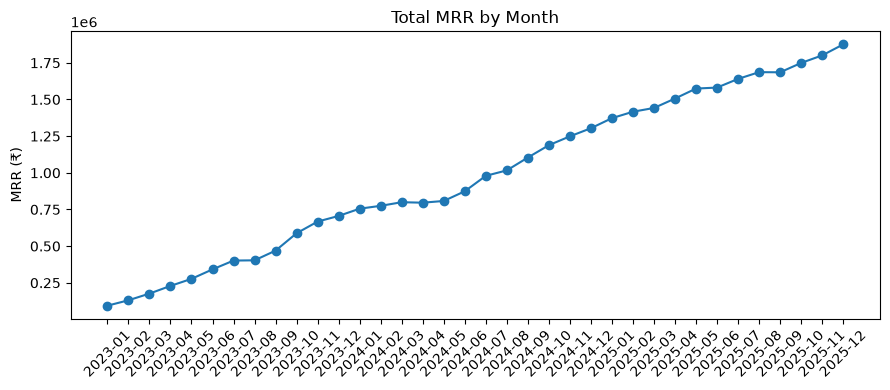

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(
    waterfall.index,
    waterfall["total_mrr"],
    marker="o"
)

ax.set_title("Total MRR by Month")
ax.set_ylabel("MRR (₹)")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

plt.savefig(
    "total_mrr_trend.png",
    dpi=150
)

plt.show()

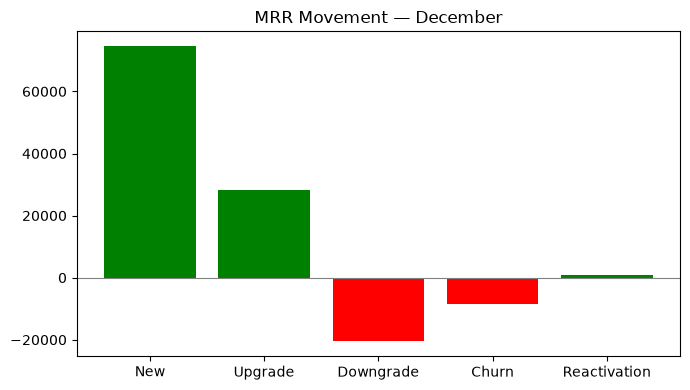

In [ ]:
month_data = waterfall.loc[
    "2025-12",
    [
        "New",
        "Upgrade",
        "Downgrade",
        "Churn",
        "Reactivation"
    ]
]

colors = [
    "green" if v >= 0 else "red"
    for v in month_data
]

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(
    month_data.index,
    month_data.values,
    color=colors
)

ax.set_title("MRR Movement — December")
ax.axhline(
    0,
    color="gray",
    linewidth=0.8
)

plt.tight_layout()

plt.savefig(
    "mrr_waterfall_dec.png",
    dpi=150
)

plt.show()

## Step 8 — Seaborn: distribution and comparison visuals

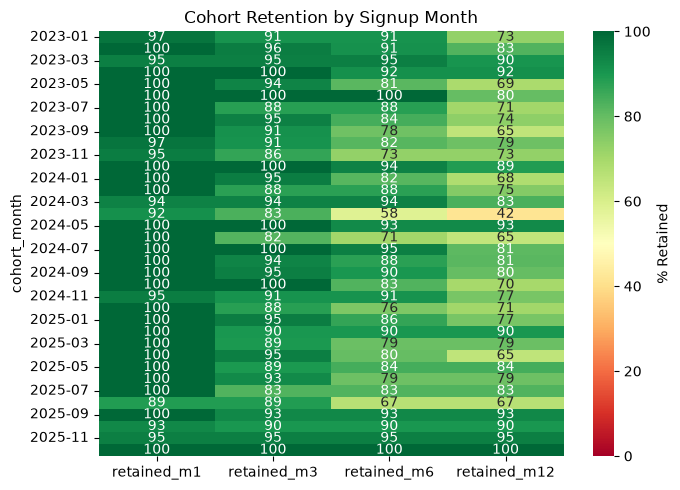

In [ ]:
# Cohort retention heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cohort_matrix, annot=True, fmt=".0f", cmap="RdYlGn", vmin=0, vmax=100, cbar_kws={"label": "% Retained"})
plt.title("Cohort Retention by Signup Month")
plt.tight_layout()
plt.savefig("cohort_retention_heatmap.png", dpi=150)
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2912\3943191939.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_by_cycle, x="billing_cycle", y="is_churned", palette=["#E2637A", "#3FC1A0"])


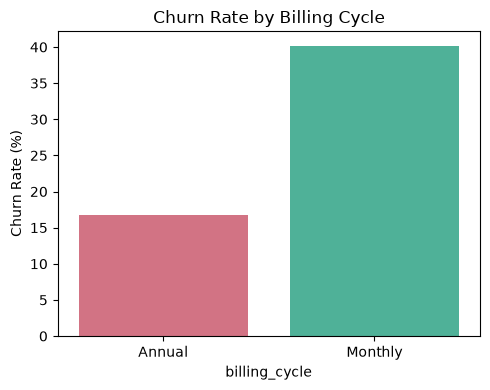

In [ ]:
# Churn rate by billing cycle
churn_by_cycle = (customers.groupby("billing_cycle")["is_churned"].mean() * 100).reset_index()
plt.figure(figsize=(5, 4))
sns.barplot(data=churn_by_cycle, x="billing_cycle", y="is_churned", palette=["#E2637A", "#3FC1A0"])
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Billing Cycle")
plt.tight_layout()
plt.savefig("churn_by_billing_cycle.png", dpi=150)
plt.show()

## Step 9 — Statistical test: chi-square

In [ ]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(customers["billing_cycle"], customers["is_churned"])
print(contingency)

chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square statistic: {chi2:.2f}")
print(f"p-value: {p_value:.5f}")

if p_value < 0.05:
    print("Statistically significant difference in churn rate by billing cycle.")
else:
    print("No statistically significant difference detected.")

is_churned     False  True 
billing_cycle              
Annual           183     37
Monthly          292    196

Chi-square statistic: 36.38
p-value: 0.00000
Statistically significant difference in churn rate by billing cycle.


In [34]:
pd.crosstab(
    events_clean["event_type"],
    [
        events_clean["plan_before"].isna(),
        events_clean["plan_after"].isna()
    ]
)

plan_before  False       True 
plan_after   False True  False
event_type                    
Churn            0   240     0
Downgrade      117     0     0
New              0     0   708
Reactivation     0     0    35
Upgrade        171     0     0

In [35]:
customers.to_csv(
    "customers_analysis.csv",
    index=False
)